# Texas Data Repository metadata assessment script

In [1]:
import json
import os
import pandas as pd
import requests
import time
from datetime import datetime
from utils import env_bool, retrieve_all_institutions

### Dates

Both for filenames and in order to calculate how long the script takes, we define two timestamps. These can then be dynamically called through the script.

In [2]:
#setting timestamp at start of script to calculate run time
start_time = datetime.now() 
#creating variable with current date for appending to filenames
today = datetime.now().strftime('%Y%m%d') 

### Config file and .env file
Parameters for the analysis are split across two files: *config.json*, which holds non-secret, generally-stable settings (toggles, API pagination limits), and *.env*, which holds your Dataverse API token and the handful of settings that are specific to you or your institution. Externalizing these parameters keeps the script clean, since most of them don't need to be updated regularly, and separating out the *.env* file protects sensitive information like API keys. The *.env* file should never be distributed to anyone else; instead, share the *.env.example* file. *config.json* has no secrets in it and can be shared/committed freely.

In [3]:
#read in config file (non-secret settings) and .env (secrets/per-user settings)
from dotenv import load_dotenv
load_dotenv()

with open('config.json', 'r') as file:
    config = json.load(file)

In [4]:
#toggle for test environment (incomplete run, faster to complete)
test = env_bool('TEST_ENVIRONMENT')
#toggle to only look at your/one institution in TDR
only_my_institution = env_bool('ONLY_MY_INSTITUTION')
#toggle for excluding unpublished
exclude_drafts = env_bool('EXCLUDE_DRAFTS')
if exclude_drafts:
    status = 'publicationStatus:Published'
else:
    status = ''

Because you can't 'comment out' remarks in a JSON file in the same way that you can with Python, I want to provide some comments on what's in these files below. The first example is showing you the institution-specific settings, which now live in *.env* as plain `KEY=value` pairs (`INSTITUTION_NAME`, `INSTITUTION_FILENAME`, `INSTITUTION_UNIQUE_IDENTIFIER`, `INSTITUTION_ROR`, `MY_INSTITUTION`, `INSTITUTION_SUBTREE`). You will want to modify these for your own institution.

In [5]:
my_institution = {
    'name': os.environ.get('INSTITUTION_NAME'),
    'filename': os.environ['INSTITUTION_FILENAME'],
    'uniqueIdentifier': os.environ.get('INSTITUTION_UNIQUE_IDENTIFIER'),
    'ror': os.environ.get('INSTITUTION_ROR'),
    'myInstitution': os.environ['MY_INSTITUTION'],
    'subtree': os.environ['INSTITUTION_SUBTREE']
}
print(my_institution)

{'name': 'University of Texas at Austin', 'filename': 'UT-austin', 'uniqueIdentifier': 'Austin', 'ror': 'https://ror.org/00hj54h04', 'myInstitution': 'UT Austin', 'subtree': 'utexas'}


You don't need to load in sequential levels of a nested object; you can go directly to the field you want, as shown below. 

In [6]:
##read in filename version of your institution's name
my_institution_filename = os.environ['INSTITUTION_FILENAME']
###condition what goes in the filename based on toggle for which institution(s) to ping
if only_my_institution:
    institution_filename = my_institution_filename
else:
    institution_filename = 'all-institutions'
##read in short-hand version of your institution's name
my_institution_short_name = os.environ['MY_INSTITUTION']

print(f'String to add to filenames: {my_institution_filename}.\n')
print(f'Short hand version of institution name: {my_institution_short_name}.\n')

String to add to filenames: UT-austin.

Short hand version of institution name: UT Austin.



The 'VARIABLES' field is what dictates the size of the retrieval to be made. Limits on attributes like page size (how many in one call), page count (how many in a total call), and starting parameters will be defined in API documentation: https://guides.dataverse.org/en/latest/api/index.html. Each API is slightly different, so you will need to adapt code based on the API. This script only uses the Dataverse API, but if you need help with the Crossref, DataCite, Dryad, Figshare, OpenAlex, or Zenodo APIs, reach out to Bryan who has code for all of these. For this specific script, you should (be able to) leave these API parameters as is. The following variable is only called here to show the entire field; the actual parameters utilized are called directly later on.

In [7]:
api_params = config['VARIABLES']
print(api_params)

{'PAGE_SIZES': {'datacite_prod': 1000, 'datacite_test': 200, 'dataverse_prod': 200, 'dataverse_test': 10}, 'PAGE_LIMITS': {'dspace_test': 3, 'dspace_prod': 100, 'tdr_test': 3, 'tdr_prod': 100}, 'PAGE_STARTS': {'datacite': 0, 'dataverse': 0}, 'PAGE_INCREMENTS': {'dataverse': 1}}


**Can you just tell me what I need to do with the *.env* file?**

There are only three things you need to change in this file to tailor it for another institution:

* **Add your Dataverse API token**: set `DATAVERSE_TOKEN` in *.env* (blank in *.env.example*). In order to get your token, log into TDR, go to your name at the top right, and click the dropdown arrow - you should see an API token button. Do not share your token!
* **Update `INSTITUTION_FILENAME`**: this is the string that will automatically be baked into filenames (so that you don't have to manually go through and change many lines of code). This can be whatever you want.
* **Update `MY_INSTITUTION`**: this is a controlled vocabulary that I cooked up for this workflow. Pick your institution out of the following:
  * 'Baylor U'
  * 'Lamar U'
  * 'SMU'
  * 'TAMU'
  * 'TAMU Galveston'
  * 'TAMIU'
  * 'Texas State U'
  * 'Texas Tech U'
  * 'Texas Women's U'
  * 'U Houston'
  * 'UNT-HSC'
  * 'UT Arlington'
  * 'UT Austin'
  * 'UTHSCSA'
  * 'UT Southwestern'

### Remaining set-up

The next few blocks handle the rest of the the setting up of the scripting process. The first step is to create some directories. This script is pretty simple, but in order to ensure that files are consistently saved and read from the same places for everyone, the script will first look for certain subdirectories in the folder where this script is contained and make them if they don't exist. As you can see, if the 'Test' toggle is enabled, it will make a *test* subdirectory and change the directory to *test.* So test and non-test outputs are separated to avoid any confusion.

In [8]:
#getting script directory
script_directory = os.getcwd()
print(f'The script directory is {script_directory}.\n')

#creating directories
if test:
    if os.path.isdir('test'):
        print('test directory found - no need to recreate')
    else:
        os.mkdir('test')
        print('test directory has been created')
    os.chdir('test')
    if os.path.isdir('outputs'):
        print('test outputs directory found - no need to recreate')
    else:
        os.mkdir('outputs')
        print('test outputs directory has been created')
else:
    if os.path.isdir('outputs'):
        print('outputs directory found - no need to recreate')
    else:
        os.mkdir('outputs')
        print('outputs directory has been created')

The script directory is c:\Users\bmg3525\OneDrive - The University of Texas at Austin\Documents\scripts\tdr-assessment-scripts.

test directory found - no need to recreate
test outputs directory found - no need to recreate


#### Basic API params

The next step is basic API parameters. This block defines the first API endpoint (the [Search API](https://guides.dataverse.org/en/latest/api/search.html)). It then dynamically calls in certain parameters about retrieval size limits from the *config.json* file, with different values based on whether you are in the Test mode. The API key is also called in from *.env*. The value '*k*' is kept in here, instead of *config.json*, because it should always be set as zero (i.e. don't touch that). It's used to count pages while the API call is being made. The *query* value is set as the DOI prefix for all TDR deposits - this is because you cannot do a blank search through the API, so you need a value that you know will return 100% of datasets.

In [9]:
print('Beginning to define API call parameters.')
url_tdr = 'https://dataverse.tdl.org/api/search/'

##set API-specific params
###Dataverse
if test and only_my_institution:
    page_limit_dataset = config['VARIABLES']['PAGE_LIMITS']['tdr_test'] 
elif test and not only_my_institution: 
    page_limit_dataset = config['VARIABLES']['PAGE_LIMITS']['tdr_test'] // 2 #halve page size if retrieving all institutions
elif not test:
    page_limit_dataset = config['VARIABLES']['PAGE_LIMITS']['tdr_prod']
page_size_dataset = config['VARIABLES']['PAGE_SIZES']['dataverse_test'] if test else config['VARIABLES']['PAGE_SIZES']['dataverse_prod']

print(f'Retrieving {page_size_dataset} records per page over {page_limit_dataset} pages.')

query = '*'
page_start_dataset = config['VARIABLES']['PAGE_STARTS']['dataverse']
page_increment_dataset = config['VARIABLES']['PAGE_INCREMENTS']['dataverse']
k = 0

headers_tdr = {
    'X-Dataverse-key': os.environ['DATAVERSE_TOKEN']
}

Beginning to define API call parameters.
Retrieving 10 records per page over 1 pages.


#### Institution-specific parameters

The next codeblock is using what's called the 'subtree'; this is a field that contains a unique code for each institution and directs to your institution's specific dataverse. Each institution has its own set of parameters, which are largely constant between them except for the subtree, defined.

In [10]:
params_tdr_ut_austin = {
    'q': query,
    'fq': status,
    'subtree': 'utexas',
    'type': 'dataset',
    'start': page_start_dataset,
    'page': page_increment_dataset,
    'per_page': page_limit_dataset
}

params_tdr_baylor = {
    'q': query,
    'fq': status,
    'subtree': 'baylor',
    'type': 'dataset',
    'start': page_start_dataset,
    'page': page_increment_dataset,
    'per_page': page_limit_dataset
}

params_tdr_lamar = {
    'q': query,
    'fq': status,
    'subtree': 'lamar',
    'type': 'dataset',
    'start': page_start_dataset,
    'page': page_increment_dataset,
    'per_page': page_limit_dataset
}

params_tdr_smu = {
    'q': query,
    'fq': status,
    'subtree': 'smu',
    'type': 'dataset',
    'start': page_start_dataset,
    'page': page_increment_dataset,
    'per_page': page_limit_dataset
}

params_tdr_tamu = {
    'q': query,
    'fq': status,
    'subtree': 'tamu',
    'type': 'dataset',
    'start': page_start_dataset,
    'page': page_increment_dataset,
    'per_page': page_limit_dataset
}

params_tdr_txst = {
    'q': query,
    'fq': status,
    'subtree': 'txst',
    'type': 'dataset',
    'start': page_start_dataset,
    'page': page_increment_dataset,
    'per_page': page_limit_dataset
}

params_tdr_ttu = {
    'q': query,
    'fq': status,
    'subtree': 'ttu',
    'type': 'dataset',
    'start': page_start_dataset,
    'page': page_increment_dataset,
    'per_page': page_limit_dataset
}

params_tdr_houston = {
    'q': query,
    'fq': status,
    'subtree': 'uh',
    'type': 'dataset',
    'start': page_start_dataset,
    'page': page_increment_dataset,
    'per_page': page_limit_dataset
}

params_tdr_hscfw = {
    'q': query,
    'fq': status,
    'subtree': 'unthsc',
    'type': 'dataset',
    'start': page_start_dataset,
    'page': page_increment_dataset,
    'per_page': page_limit_dataset
}

params_tdr_tamug = {
    'q': query,
    'fq': status,
    'subtree': 'tamug',
    'type': 'dataset',
    'start': page_start_dataset,
    'page': page_increment_dataset,
    'per_page': page_limit_dataset
}
params_tdr_tamui = {
    'q': query,
    'fq': status,
    'subtree': 'tamiu',
    'type': 'dataset',
    'start': page_start_dataset,
    'page': page_increment_dataset,
    'per_page': page_limit_dataset
}
params_tdr_utsah = {
    'q': query,
    'fq': status,
    'subtree': 'uthscsa',
    'type': 'dataset',
    'start': page_start_dataset,
    'page': page_increment_dataset,
    'per_page': page_limit_dataset
}
params_tdr_utswm = {
    'q': query,
    'fq': status,
    'subtree': 'utswmed',
    'type': 'dataset',
    'start': page_start_dataset,
    'page': page_increment_dataset,
    'per_page': page_limit_dataset
}

params_tdr_uta = {
    'q': query,
    'fq': status,
    'subtree': 'uta',
    'type': 'dataset',
    'start': page_start_dataset,
    'page': page_increment_dataset,
    'per_page': page_limit_dataset
}

params_tdr_twu = {
    'q': query,
    'fq': status,
    'subtree': 'twu',
    'type': 'dataset',
    'start': page_start_dataset,
    'page': page_increment_dataset,
    'per_page': page_limit_dataset
}

#### Parameter combinations

The next codeblock is setting up the code to handle different conditions based on whether you want to look at only your institution or all TDR institutions. The *all_params* object combines all of the institution-specific parameters. The *tamu_combined_params* object combines only TAMU parameters. In theory, you can cook up any combination you want (e.g., UT system schools).

In [ ]:
all_params_datasets = {
        'UT Austin': params_tdr_ut_austin,
        'Baylor U': params_tdr_baylor,
        'SMU': params_tdr_smu,
        'TAMU': params_tdr_tamu,
        'Texas State U': params_tdr_txst,
        'Texas Tech U': params_tdr_ttu,
        'U Houston': params_tdr_houston,
        'UNT-HSC': params_tdr_hscfw,
        'TAMU Galveston': params_tdr_tamug,
        'TAMIU': params_tdr_tamui,
        'UTHSCSA': params_tdr_utsah,
        'UT Southwestern': params_tdr_utswm,
        'Lamar U': params_tdr_lamar,
        'UT Arlington': params_tdr_uta,
        "Texas Women's U": params_tdr_twu
    }

The next codebook then uses 'if-else' statements to tell the script which combination (or single-institution parameter set) to use. The script is basically saying:

* if you set the *only_my_institution* toggle to TRUE, AND you set the *my_institution_short_name* to 'TAMU,' then I will use the combined TAMU parameter set (*tamu_combined_params*).
* if you set the *only_my_institution* toggle to TRUE, BUT you set the *my_institution_short_name* to anything other than 'TAMU,' then I will use the single institution parameter set (e.g., *params_tdr_ut_austin* for UT Austin).
* if you set the *only_my_institution* toggle to FALSE, then I will search across all institutions with *all_params*.

In [12]:
#substitute for your institution
if only_my_institution:
    params_list = {
        my_institution_short_name: all_params_datasets[my_institution_short_name]
    }
else:
    params_list = all_params_datasets

## Retrieval process: part 1

Because we defined a series of functions related to retrieving records from the Dataverse API, potentially across all institutions, the process to trigger the API call is a single line with the *retrieve_all_institutions* function, as seen below. 

In [13]:
print('Starting TDR retrieval.\n')
all_data = retrieve_all_institutions(url_tdr, params_list, headers_tdr, page_start_dataset, page_size_dataset, page_limit_dataset)

Starting TDR retrieval.

Retrieving page 1 of 162 pages...

Reached page limit.

Retrieving page 1 of 17 pages...

Reached page limit.

Retrieving page 1 of 3 pages...

Reached page limit.

Retrieving page 1 of 61 pages...

Reached page limit.

Retrieving page 1 of 23 pages...

Reached page limit.

Retrieving page 1 of 16 pages...

Reached page limit.

Retrieving page 1 of 8 pages...

Reached page limit.

Retrieving page 1 of 2 pages...

End of response.

Retrieving page 1 of 6 pages...

Reached page limit.

Retrieving page 1 of 6 pages...

Reached page limit.

Retrieving page 1 of 3 pages...

Reached page limit.

Retrieving page 1 of 13 pages...

Reached page limit.

Retrieving page 1 of 5 pages...

Reached page limit.

Retrieving page 1 of 2 pages...

End of response.



### Subsetting API response

After the call, the API response is cached in the system but not saved in any form. You could, if you wanted to, export it as a JSON file, but I prefer working in CSV / tabular format for a lot of this work, so we'll convert it to a dataframe first. The first step in that is selecting certain fields that we want; not all fields are useful. 

**Why not just explode each JSON field into a separate Excel column (e.g., *authors* becomes *authors_1*, *authors_2*, etc.)?**

I actually used to do this when I was developing another Python workflow (https://github.com/utlibraries/research-data-discovery). What I discovered is that, given any appreciable number of dataset records (let's say more than 250), at least one is virtually guaranteed to have an inordinate number of nested fields (e.g., 29 authors). This means that the script will flatten just that one field into 29 columns, which takes a lot longer to do and a lot longer to work through. If you start getting up above 1,000 records, you might not have enough RAM to actually do this. When we know what fields are important, we can just subset for them.

**Why are we subsetting so few fields?** 

The Search API endpoint returns relatively little metadata because it's intended for a broad capture (one call, many results). It doesn't even return information like author affiliations. So the main purpose of this call is just to get every single dataset of interest, and then we'll pass the DOIs into a different API endpoint to get more detailed metadata.

The way that this first subsetting process works is to create an empty list to hold the subsetted output (*data_select_tdr*) and then to loop through the full API response (*all_data*), pulling out specific fields. The syntax (e.g., *item.get*) is based on the hierarchy of the output. You'll see in later processes how we'll need to extract more nested objects. The script then appends each dataset's subsetted metadata into the list, and we convert it to a dataframe with the *pandas* library.

In [14]:
print('Starting TDR filtering.\n')
data_select_tdr = []
for item in all_data:
    id = item.get('global_id', '')
    type = item.get('type', '')
    institution = item.get('institution','')
    status = item.get('versionState', '')
    name = item.get('name', '')
    dataverse = item.get('name_of_dataverse', '')
    majorV = item.get('majorVersion', 0)
    minorV = item.get('minorVersion', 0)
    comboV = f'{majorV}.{minorV}'
    version_id = item.get('versionId', '')
    data_select_tdr.append({
        'institution': institution, 
        'doi': id,
        'type': type,
        'status': status,
        'dataset_title': name,
        'dataverse': dataverse
    })

df_data_select_tdr = pd.DataFrame(data_select_tdr)

Starting TDR filtering.



#### Post-conversion cleaning

We'll do a little bit of cleaning / modification of the data now that they're in a dataframe. The first step (filtering for 'type' = 'dataset') is redundant now because the 'type' is specified in the API call (this omits retrieval of 'dataverse' and 'file' records), but it's retained because it doesn't take up any more time and can be useful if you change the parameters later. The two other steps edit the DOI field to remove a 'doi:' string that always precedes the DOI value in that column and to add a Boolean column indicating whether a dataset has been versioned or not.

In [15]:
#remove dataverses and files
filtered_tdr = df_data_select_tdr[df_data_select_tdr['type'] == 'dataset']
#editing DOI field
filtered_tdr['doi'] = filtered_tdr['doi'].str.replace('doi:', '')

## Retrieval process: part 2

The next part of the process is where we get richer metadata. In this step, we go through the [Native API](https://guides.dataverse.org/en/latest/api/native-api.html). This endpoint requires you to feed a single DOI into it, and then it returns very detailed, file-level metadata for the latest version of the dataset (regardless of publication status). 

First, however, we need to deal with a quirk of the Search API: that it returns two records for any dataset that has been previously published and that is now in draft status. These records could be functionally identical (e.g., author accidentally puts published dataset into draft mode, strands it there without making changes) or quite significantly different. The code below de-duplicates these records, retaining only the published version, but saves a CSV file with a list of pairs of records with this status.

In [16]:

#sort on status, setting 'DRAFT' at bottom to remove this version for published datasets that are in draft state, retain entry of 'PUBLISHED'
filtered_tdr = filtered_tdr.sort_values(by='status', ascending=False)
filtered_tdr.to_csv(f'outputs/{today}_{institution_filename}_all-deposits.csv')
filtered_tdr_deduplicated = filtered_tdr.drop_duplicates(subset=['doi'], keep='first')
filtered_tdr_deduplicated.to_csv(f'outputs/{today}_{institution_filename}_all-deposits-deduplicated.csv')
print(f'Total datasets to be analyzed: {len(filtered_tdr_deduplicated)}.\n')

#create df of published datasets with draft version (retains both entries)
commonColumns = ['doi', 'dataset_title']
duplicates = filtered_tdr.duplicated(subset=commonColumns, keep=False)
dual_status_datasets = filtered_tdr[duplicates]
dual_status_datasets.to_csv(f'outputs/{today}_{institution_filename}_dual-status-datasets.csv')

Total datasets to be analyzed: 129.



Now we have a list of unique DOIs that we want more metadata on. The following code makes a similar API call to the first one, but through the Native API endpoint. So we define the endpoint (it's a different URL) and then set up a 'for loop,' where we go through each DOI in the de-duplicated dataframe, get its metadata, and save that in an empty list called *results*. Sometimes the API is unstable and will timeout for a certain DOI, so the script also records those and will retry them again with a longer time-out and a longer delay between queries and then return a list of ones that failed again. The idea is to both write these to a log file in the future and to maybe increase the number of retries - this should not be related to a specific dataset but rather to the API's stability.

In [17]:
#retrieving additional metadata for deposits by individual API call (one per DOI)
##retrieves both published and never-published draft datasets; if a published dataset is currently in DRAFT state, it will return the information for the DRAFT state
print('Starting Native API call')
url_tdr_native = 'https://dataverse.tdl.org/api/datasets/'

print(f'Total datasets to be analyzed: {len(filtered_tdr_deduplicated)}.\n')

results = []
initial_timeouts = []
final_timeouts = []
for doi in filtered_tdr_deduplicated['doi']:
    try:
        response = requests.get(f'{url_tdr_native}:persistentId/?persistentId=doi:{doi}', headers=headers_tdr, timeout=5)
        if response.status_code == 200:
            print(f'Retrieving {doi}\n')
            results.append(response.json())
        else:
            final_timeouts.append({'doi': doi, "reason": f"Status {response.status_code}"})
            
    except requests.exceptions.Timeout:
        initial_timeouts.append(doi)
    except requests.exceptions.RequestException as e:
        final_timeouts.append({"doi": doi, "reason": str(e)})

if initial_timeouts:
    print(f"\n--- Retrying {len(initial_timeouts)} timeouts with 10s limit ---\n")
    time.sleep(2) 
    
    for doi in initial_timeouts:
        try:
            response = requests.get(
                f'{url_tdr_native}:persistentId/?persistentId=doi:{doi}', 
                headers=headers_tdr, 
                timeout=10 
            )
            if response.status_code == 200:
                print(f'Retrying {doi}\n')
                results.append(response.json())
            else:
                final_timeouts.append({"doi": doi, "reason": f"Retry Status {response.status_code}"})
        except Exception as e:
            final_timeouts.append({"doi": doi, "reason": "Persistent Timeout/Error"})

data_tdr_native = {
    'datasets': results
}

Starting Native API call
Total datasets to be analyzed: 129.

Retrieving 10.18738/T8/TXQVOJ

Retrieving 10.18738/T8/B1U1S2

Retrieving 10.18738/T8/XRHVYM

Retrieving 10.18738/T8/9UXITA

Retrieving 10.18738/T8/OMUBK8

Retrieving 10.18738/T8/MGWNSN

Retrieving 10.18738/T8/920BS9

Retrieving 10.18738/T8/55MZ8F

Retrieving 10.18738/T8/0ZHUS1

Retrieving 10.18738/T8/XIA0OF

Retrieving 10.18738/T8/YYHQLQ

Retrieving 10.18738/T8/YQ9PSJ

Retrieving 10.18738/T8/VSI8CF

Retrieving 10.18738/T8/TNOF0T

Retrieving 10.18738/T8/N2UULG

Retrieving 10.18738/T8/VRYGDS

Retrieving 10.18738/T8/1Z6NGR

Retrieving 10.18738/T8/K9KNLC

Retrieving 10.18738/T8/TPHGGK

Retrieving 10.18738/T8/X1Z95U

Retrieving 10.18738/T8/HWFP9O

Retrieving 10.18738/T8/OVVTRD

Retrieving 10.18738/T8/FY2161

Retrieving 10.18738/T8/6WVJZG

Retrieving 10.18738/T8/KIL0NI

Retrieving 10.18738/T8/VTCOMT

Retrieving 10.18738/T8/BPJBUX

Retrieving 10.18738/T8/QH9NXV

Retrieving 10.18738/T8/WGNMFL

Retrieving 10.18738/T8/HZ1VPM

Retrievi

Then we do a similar subsetting process to what we did for the first API call. We make an empty list to store the output (*data_select_tdr_native*) and then loop through. You might notice that there are various *X.get* commands in the script below. This is based on the nesting of different fields. For example, *latest* is nested within *data*, so in order to get anything that is nested under *latest*, we need to define that one first. The only way to know how to structure this is to look at an actual API response. You'll see that we're subsetting a lot more fields and getting a lot more detail in the metadata. This code specifically creates an entry for each file listed in a dataset record, so some dataset-level metadata is duplicated across several rows.

In [18]:
print('Beginning dataframe subsetting\n')
data_select_tdr_native = [] 
for item in data_tdr_native['datasets']:
    data = item.get('data', '')
    pubDate = data.get('publicationDate', '')
    latest = data.get('latestVersion', {})
    status = latest.get('versionState', '')
    status2 = latest.get('latestVersionPublishingState', '')
    doi = latest.get('datasetPersistentId', '')
    citation = latest.get('metadataBlocks', {}).get('citation', {})
    fields = citation.get('fields', [])
    # Initialize fields as empty in case no entries have them
    grant_agencies = None
    subtitle = None
    alt_title = None
    alt_url = None
    keywords_str = None
    language = None
    topics = None
    notes = None
    depositor = None
    contacts = None
    contact_emails = None
    producer_str = None
    publications_str = None
    alt_id = None
    num_contributors = 0
    num_contributors_types = 0
    num_contributors_names = 0
    num_distributors = 0
    num_distributors_affiliations = 0
    num_distributors_names = 0
    production_date = None
    production_place = None
    distribution_date = None
    period_starts_str = None
    period_ends_str = None
    collection_starts_str = None
    collection_ends_str = None
    data_type = None
    related_material = None
    related_dataset = None
    other_refs = None
    data_source = None
    source_origin = None
    source_characteristic = None
    source_access = None

    for field in fields:
        if field['typeName'] == 'subtitle':
            subtitle = field.get('value', '')
        if field['typeName'] == 'alternativeTitle':
            alt_title = field.get('value', '')
        if field['typeName'] == 'alternativeURL':
            alt_url = field.get('value', '')
        if field['typeName'] == 'otherId':
            alt_ids = []
            for other_id_dict in field.get('value', []):
                alt_id = other_id_dict.get('otherIdValue', {}).get('value', '')
                if alt_id:
                    alt_ids.append(alt_id)
            alt_id = '; '.join(alt_ids)
        if field['typeName'] == 'topicClassification':
            topics = []
            for topic in field.get('value', []):
                topic_value = topic.get('value', '')
                topics.append(topic_value)
        if field['typeName'] == 'language':
            language = field.get('value','')
        if field['typeName'] == 'grantNumber':
            grant_agencies = []
            for grant in field.get('value', []):
                grant_number_agency = grant.get('grantNumberAgency', {}).get('value', '')
                grant_agencies.append(grant_number_agency)
        if field['typeName'] == 'subject':
            subjects = field.get('value', [])
        if field['typeName'] == 'dsDescription':
            for descrip in field.get('value', []):
                description = descrip.get('dsDescriptionValue', {}).get('value','')
                description_date = descrip.get('dsDescriptionDate', {}).get('value','')
        if field['typeName'] == 'notesText':
            notes = field.get('value', '')
        if field['typeName'] == 'keyword':
            keywords = []
            for keyword_dict in field.get('value', []):
                keyword_value = keyword_dict.get('keywordValue', {}).get('value', '')
                if keyword_value:
                    keywords.append(keyword_value)
            keywords_str = '; '.join(keywords)
        if field['typeName'] == 'datasetContact':
            contacts = []
            contact_emails = []
            num_contacts = 0
            num_contacts_affils = 0
            num_contacts_emails = 0
            for contact in field.get('value', []):
                num_contacts += 1
                contact_value = contact.get('datasetContactName', {}).get('value', '')
                contact_affiliation_value = contact.get('datasetContactAffiliation', {}).get('value','')
                contact_email_value = contact.get('datasetContactEmail', {}).get('value', '')
                if contact_value:
                    contacts.append(contact_value)
                if contact_email_value:
                    contact_emails.append(contact_email_value)
                    num_contacts_emails += 1
                if contact_affiliation_value:
                    num_contacts_affils += 1
            contacts = '; '.join(contacts) 
            contact_emails = '; '.join(contact_emails)
        if field['typeName'] == 'depositor':
            depositor = field.get('value', '')
        if field['typeName'] == 'author':
            num_authors = 0
            num_affiliations = 0
            num_identifiers = 0
            for author in field.get('value', []):
                num_authors += 1
                if author.get('authorAffiliation', {}).get('value', ''):
                    num_affiliations += 1
                if author.get('authorIdentifier', {}).get('value', ''):
                    num_identifiers += 1
        if field['typeName'] == 'contributor':
            num_contributors = 0
            num_contributors_types = 0
            num_contributors_names = 0
            for contributor in field.get('value', []):
                num_contributors += 1
                if contributor.get('contributorType', {}).get('value', ''):
                    num_contributors_types += 1
                if contributor.get('contributorName', {}).get('value', ''):
                    num_contributors_names += 1
        if field['typeName'] == 'distributor':
            num_distributors = 0
            num_distributors_affiliations = 0
            num_distributors_names = 0
            for distributor in field.get('value', []):
                num_distributors += 1
                if distributor.get('distributorAffiliation', {}).get('value', ''):
                    num_distributors_affiliations += 1
                if distributor.get('distributorName', {}).get('value', ''):
                    num_distributors_names += 1
        if field['typeName'] == 'producer':
            producers = []
            for producer_dict in field.get('value', []):
                producer_name = producer_dict.get('producerName', {}).get('value', '')
                if producer_name:
                    producers.append(producer_name)
            producer_str = '; '.join(producers)
        if field['typeName'] == 'publication':
            publications = []
            for pub_dict in field.get('value', []):
                publication_citation = pub_dict.get('publicationCitation', {}).get('value', '')
                if publication_citation:
                    publications.append(publication_citation)
            publications_str = '; '.join(publications)
        if field['typeName'] == 'productionDate':
            production_date = field.get('value', '')
        if field['typeName'] == 'productionPlace':
            production_place = field.get('value', '')
        if field['typeName'] == 'dateOfDeposit':
            deposit_date = field.get('value', '')
        if field['typeName'] == 'distributionDate':
            distribution_date = field.get('value', '')
        if field['typeName'] == 'timePeriodCovered':
            period_starts = []
            period_ends = []
            for date in field.get('value', []):
                period_start = date.get('timePeriodCoveredStart', {}).get('value', '')
                if period_start:
                    period_starts.append(period_start)
            period_starts_str = '; '.join(period_starts)
            for date in field.get('value', []):
                period_end = date.get('timePeriodCoveredEnd', {}).get('value', '')
                if period_end:
                    period_ends.append(period_end)
            period_ends_str = '; '.join(period_ends)
        if field['typeName'] == 'dateOfCollection':
            collection_starts = []
            collection_ends = []
            for date in field.get('value', []):
                collection_start = date.get('dateOfCollectionStart', {}).get('value', '')
                if collection_start:
                    collection_starts.append(collection_start)
            collection_starts_str = '; '.join(collection_starts)
            for date in field.get('value', []):
                collection_end = date.get('dateOfCollectionEnd', {}).get('value', '')
                if collection_end:
                    collection_ends.append(collection_end)
            collection_ends_str = '; '.join(collection_ends)
        if field['typeName'] == 'kindOfData':
            data_type = field.get('value', '')
        if field['typeName'] == 'relatedMaterial':
            related_material = field.get('value', '')
        if field['typeName'] == 'relatedDatasets':
            related_dataset = field.get('value', '')
        if field['typeName'] == 'otherReferences':
            other_refs = field.get('value', '')
        if field['typeName'] == 'dataSources':
            data_source = field.get('value', '')
        if field['typeName'] == 'originOfSources':
            source_origin = field.get('value', '')
        if field['typeName'] == 'characteristicOfSources':
            source_characteristic = field.get('value', '')
        if field['typeName'] == 'accessToSources':
            source_access = field.get('value', '')
            
    data_select_tdr_native.append({
        'doi': doi,
        'subtitle': subtitle,
        'alt_title': alt_title,
        'alt_url': alt_url,
        'notes': notes,
        'description': description,
        'description_date': description_date,
        'keywords': keywords_str,
        'subject': subjects,
        'count_authors': num_authors,
        'count_affiliations': num_affiliations,
        'count_identifiers': num_identifiers,
        'count_contributors': num_contributors,
        'count_contributors_types': num_contributors_types,
        'count_contributors_names': num_contributors_names,
        'contact_name': contacts,
        'contact_email': contact_emails,
        'count_contacts': num_contacts,
        'count_contact_affiliations': num_contacts_affils,
        'count_contact_emails': num_contacts_emails,
        'dataset_depositor': depositor,
        'deposit_date': deposit_date,
        'producer': producer_str,
        'production_date': production_date,
        'production_place': production_place,
        'distribution_date': distribution_date,
        'period_starts_str': period_starts_str,
        'period_ends_str': period_ends_str,
        'collection_starts_str': collection_starts_str,
        'collection_ends_str': collection_ends_str,
        'related_works': publications_str,
        'related_dataset': related_dataset,
        'related_material': related_material,
        'other_refs': other_refs,
        'data_type': data_type,
        'grant_agencies': grant_agencies,
        'data_source': data_source,
        'source_origin': source_origin,
        'source_characteristic': source_characteristic,
        'source_access': source_access,
        'current_status': status2
    })

Beginning dataframe subsetting



### Initial cleaning

We then convert these subsetted responses to dataframes, standardize how the DOIs are listed, and add a column for the file-level output to create a column with just the year the file was created (from a full date).

In [19]:
df_select_tdr_native = pd.json_normalize(data_select_tdr_native)
df_select_tdr_native['doi'] = df_select_tdr_native['doi'].str.replace('doi:', '')

In [20]:
## Convert count-based values to "Boolean" blanks
field_groups = {
    'author_name': 'count_authors',
    'author_affiliation': 'count_affiliations',
    'author_identifier': 'count_identifiers'
}

# Reference field - the one all others should match
reference_field = 'count_authors'

# Create a new column for each field that shows if it matches the reference
for field_name, count_column in field_groups.items():
    # If the count matches the reference, keep the value; otherwise set to NaN
    df_select_tdr_native[f'{field_name}_complete'] = df_select_tdr_native[count_column].where(
        df_select_tdr_native[count_column] == df_select_tdr_native[reference_field], 
        pd.NA
    )

field_groups = {
    'contact_email': 'count_contact_emails',
    'contact_name': 'count_contacts',
    'contact_affiliation': 'count_contact_affiliations'
}

# Reference field - the one all others should match
reference_field = 'count_contact_emails'

# Create a new column for each field that shows if it matches the reference
for field_name, count_column in field_groups.items():
    # If the count matches the reference, keep the value; otherwise set to NaN
    df_select_tdr_native[f'{field_name}_complete'] = df_select_tdr_native[count_column].where(
        df_select_tdr_native[count_column] == df_select_tdr_native[reference_field], 
        pd.NA
    )

df_select_tdr_native['contributors_complete'] = df_select_tdr_native['count_contributors_names'].where(
    df_select_tdr_native['count_contributors_names'] != 0, 
    pd.NA
)

df_select_tdr_native['author_names'] = df_select_tdr_native['count_authors'].where(
    df_select_tdr_native['count_authors'] != 0, 
    pd.NA
)

In [21]:
df_select_concatenated = pd.merge(filtered_tdr_deduplicated, df_select_tdr_native, on='doi', how='left')
df_select_concatenated.to_csv(f'outputs/{today}_{institution_filename}_all-datasets-deduplicated_expanded-metadata.csv', index=False)

# Create separate df where time-outs are omitted
print(final_timeouts)
timed_out_dois = [item['doi'] for item in final_timeouts]
df_filtered = df_select_concatenated[~df_select_concatenated['doi'].isin(timed_out_dois)]
df_filtered.to_csv(f'outputs/{today}_{institution_filename}_cleaned-datasets.csv', index=False)


[]


In [22]:
## Binning by field type

required_fields = ['dataset_title', 'contact_email', 'author_names', 'description', 'subjects', 'production_date', 'production_place', 'data_type']
optional_auto_populated = ['dataset_depositor', 'deposit_date']
optional_displayed_creation = ['author_affiliation_complete', 'author_identifier_complete', 'contact_name_complete', 'contact_affiliation_complete', 'description_date', 'notes', 'keywords', 'related_works', 'language', 'producer']
optional_displayed_after = ['subtitle', 'alt_title', 'alt_url', 'distribution_date', 'contributors_complete', 'period_starts_str', 'period_ends_str', 'collection_starts_str', 'collection_ends_str', 'related_dataset', 'related_material', 'other_refs', 'grant_agencies', 'data_source', 'source_origin', 'source_characteristic', 'source_access']

field_categories = {}
field_categories.update({field: 'Required' for field in required_fields})
field_categories.update({field: 'Optional, Auto-populated on Creation' for field in optional_auto_populated})
field_categories.update({field: 'Optional, Displayed on Creation' for field in optional_displayed_creation})
field_categories.update({field: 'Optional, Displayed After Creation' for field in optional_displayed_after})


## Plots

In [23]:
blank_percent = ((df_filtered.isnull() | df_filtered.isin(['', ' '])).sum() / len(df_filtered)) * 100

# Sort in descending order for better visualization
blank_percent = blank_percent.sort_values(ascending=False)

print(blank_percent)

field_info = pd.DataFrame({
    'Field': blank_percent.index,
    'Blank Percentage': blank_percent.values,
    'Category': [field_categories.get(field) for field in blank_percent.index]
})

# Remove rows where Category is None (uncategorized)
field_info = field_info[field_info['Category'].notna()]

# Sort by category and blank percentage
field_info = field_info.sort_values(['Category', 'Blank Percentage'], ascending=[True, False])

# Rename fields
field_info['Field'] = field_info['Field'].replace({'dataset_title': 'Title (main)','subtitle':'Subtitle','description':'Description (text)','description_date':'Description (date)','notes':'Notes','keywords':'Keywords','subject':'Subjects','author_names':'Author (names)','author_affiliation_complete':'Author (affiliations)', 'author_identifier_complete':'Author (identifiers)','contributors_complete':'Contributor (name)','producer':'Producer','production_place':'Production (place)','production_date':'Production (date)','dataset_depositor':'Deposit (name)','deposit_date':'Deposit (date)','contact_name_complete':'Contact (names)','contact_email':'Contact (emails)','contact_affiliation_complete':'Contact (affiliations)','alt_title':'Title (alternative)','alt_url':'URL (alternative)','period_starts_str':'Time period (start)','period_ends_str':'Time period (end)','collection_starts_str':'Collection date (start)','collection_ends_str':'Collection date (end)','related_works':'Related (publication)','related_dataset':'Related (dataset)','related_material':'Related (material)','other_refs':'Other references','distribution_date':'Distribution date','source_origin':'Source (origin)','source_access':'Source (access)','data_source':'Source (data)','source_characteristic':'Source (characteristic)','data_type':'Data type','grant_agencies':'Funders'})
field_info['Blank Percentage'] = round(field_info['Blank Percentage'], 2)
field_info['Present Percentage'] = 100 - field_info['Blank Percentage']
field_info.to_csv('outputs/missing-data-table.csv', index=False)
print(field_info)

distribution_date               100.000000
source_access                   100.000000
alt_url                         100.000000
data_source                     100.000000
source_origin                   100.000000
source_characteristic           100.000000
related_dataset                  98.449612
other_refs                       98.449612
subtitle                         98.449612
alt_title                        97.674419
related_material                 96.899225
contributors_complete            96.124031
producer                         95.348837
grant_agencies                   94.573643
collection_starts_str            93.798450
collection_ends_str              93.798450
notes                            89.147287
period_starts_str                82.170543
period_ends_str                  82.170543
author_identifier_complete       71.317829
related_works                    60.465116
keywords                         54.263566
description_date                 43.410853
author_affi

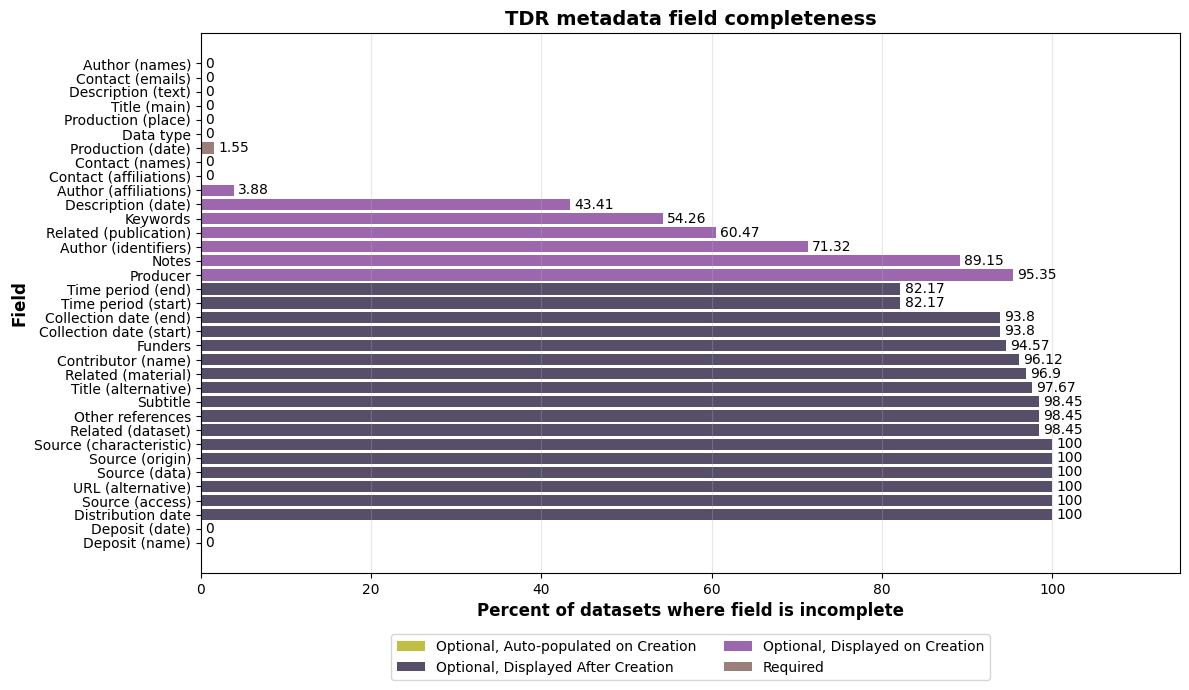

In [24]:
import matplotlib.pyplot as plt

# Assuming you have field_info dataframe from previous steps

fig, ax = plt.subplots(figsize=(12, 7))

colors = {
    'Required': "#9a7f7a", 
    'Optional, Auto-populated on Creation': "#c1be44",
    'Optional, Displayed on Creation': "#9c67ac", 
    'Optional, Displayed After Creation': "#574e69"
}

for category in field_info['Category'].unique():
    subset = field_info[field_info['Category'] == category]
    bars = ax.barh(subset['Field'], subset['Blank Percentage'], label=category, color=colors.get(category))
    ax.bar_label(bars, padding=3)

ax.set_xlabel('Percent of datasets where field is incomplete', fontsize=12, fontweight='bold')
ax.set_ylabel('Field', fontsize=12, fontweight='bold')
ax.set_title('TDR metadata field completeness', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=2)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(field_info['Blank Percentage']) + 15)  # Add space for labels
plt.tight_layout()
plt.show()

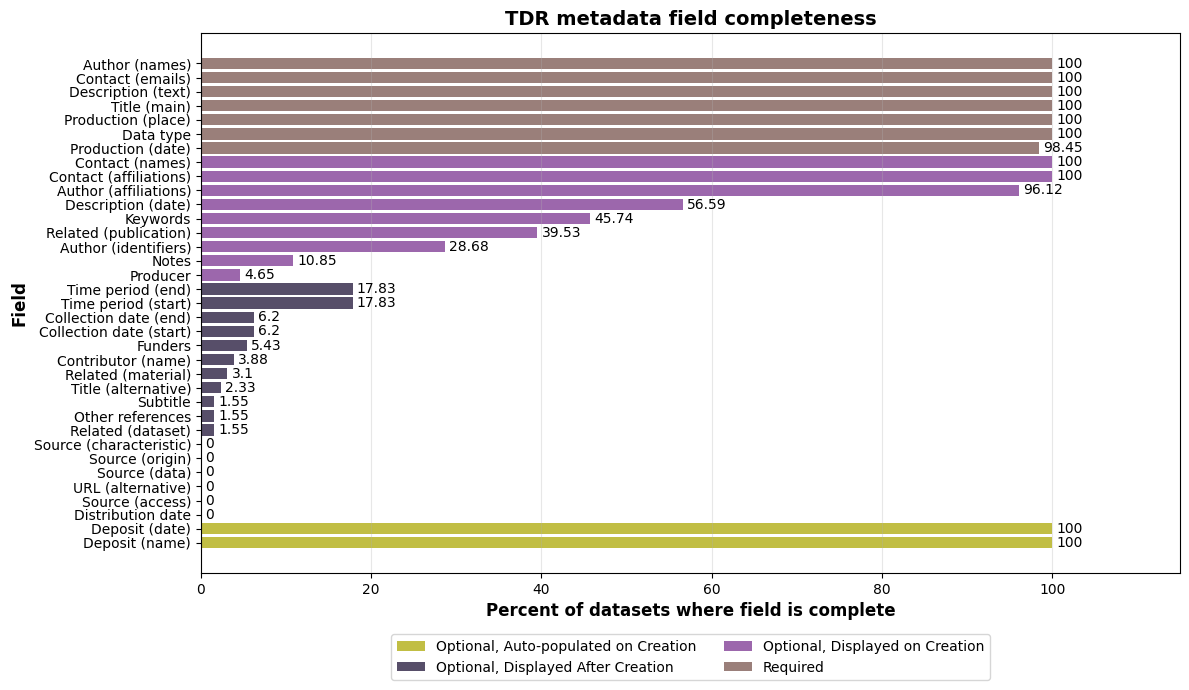

In [25]:
# Assuming you have field_info dataframe from previous steps

fig, ax = plt.subplots(figsize=(12, 7))

colors = {
    'Required': "#9a7f7a", 
    'Optional, Auto-populated on Creation': "#c1be44",
    'Optional, Displayed on Creation': "#9c67ac", 
    'Optional, Displayed After Creation': "#574e69"
}

for category in field_info['Category'].unique():
    subset = field_info[field_info['Category'] == category]
    bars = ax.barh(subset['Field'], subset['Present Percentage'], label=category, color=colors.get(category))
    ax.bar_label(bars, padding=3)

ax.set_xlabel('Percent of datasets where field is complete', fontsize=12, fontweight='bold')
ax.set_ylabel('Field', fontsize=12, fontweight='bold')
ax.set_title('TDR metadata field completeness', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=2)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(field_info['Blank Percentage']) + 15)  # Add space for labels
plt.tight_layout()
plt.show()

In [26]:
print(f'Done\n---Time to run: {datetime.now() - start_time}---\n')
if test:
    print('**REMINDER: THIS IS A TEST RUN, AND ANY RESULTS ARE NOT COMPLETE!**\n')

Done
---Time to run: 0:00:40.568808---

**REMINDER: THIS IS A TEST RUN, AND ANY RESULTS ARE NOT COMPLETE!**

